In [1]:
import pandas as pd
import geopandas as gpd
#import shapely
from shapely.geometry import Point
#from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
#import re
from shapely.wkt import loads
import numpy as np
#from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
#import altair as alt
#from scipy import ndimage
from PIL import Image
from plot_functions import plot_directional_ellipse_gdf, create_gif

In [2]:
commarea = gpd.read_file('south_chicago.geojson')
commarea.geometry = commarea.geometry.to_crs(epsg=26971)

parks_water = gpd.read_file('parks_water_no_mich_together.geojson')
parks_water = parks_water.to_crs(epsg='26971')

hom_1940 = gpd.read_file('homcide-locations_1940-1964.csv')
hom_1940.POINT_X = hom_1940.POINT_X.astype(float)
hom_1940.POINT_Y = hom_1940.POINT_Y.astype(float)
hom_1940['geometry'] = hom_1940.apply(lambda x: Point(x.POINT_X, x.POINT_Y),
                                      axis=1)
hom_1940 = gpd.GeoDataFrame(hom_1940, geometry='geometry', crs='EPSG:4326')
hom_1940 = hom_1940.to_crs(epsg=26971)
hom_1940.year = hom_1940.year.astype(float).astype(int)

hom_1870 = gpd.read_file('homicide-locations_1870-1930.csv')
hom_1870.x = hom_1870.x.astype(float)
hom_1870.y = hom_1870.y.astype(float)
hom_1870['geometry'] = hom_1870.apply(lambda a: Point(a.x, a.y),
                                      axis=1)
hom_1870 = gpd.GeoDataFrame(hom_1870, geometry='geometry', crs='EPSG:4326')
hom_1870 = hom_1870.to_crs(epsg='26971')
hom_1870.year = hom_1870.year.astype(float).astype(int)

hom_1940_south = gpd.sjoin(hom_1940, commarea, how='inner')
hom_1870_south = gpd.sjoin(hom_1870, commarea, how='inner')

hom_1965 = gpd.read_file('locs_homicide_post_65.geojson', #crs='EPSG:26971'
                         )
hom_1965.year = hom_1965.year.astype(int)
hom_1965.geometry = hom_1965.geometry.centroid
hom_1965 = hom_1965.to_crs(epsg=26971)
hom_1965_south = gpd.sjoin(hom_1965, commarea, how='inner')

commarea_west = gpd.read_file('westside.geojson')
commarea_west = commarea_west.to_crs(epsg='26971')
commarea_west.head()

hom_1870_west = gpd.sjoin(hom_1870, commarea_west, how="inner")
hom_1940_west = gpd.sjoin(hom_1940, commarea_west, how="inner")
hom_1965_west = gpd.sjoin(hom_1965, commarea_west, how="inner")

west_hom = pd.concat([hom_1870_west, hom_1940_west, hom_1965_west])

south_hom = pd.concat([hom_1870_south, hom_1940_south, hom_1965_south])

In [23]:
map_data = gpd.read_file('map_data.csv')
map_data.geometry = map_data.geometry.apply(loads)
map_data = gpd.GeoDataFrame(map_data, geometry='geometry', crs="EPSG:4326")
map_data = map_data.to_crs(epsg=26971)
map_data.head()
map_data.hom_ct = map_data.hom_ct.astype(float)
map_data.year = map_data.year.astype(int)
map_data = map_data[map_data.GRID_ID != 'AF-4'] # excluding edgewater arson case

In [4]:
def difference(df, num_year):

    df_future = df.copy()
    df_future['year'] += num_year  # Shift years backwards to align future values
    df_future = df_future.rename(columns={'hom_ct': 'past_hom_ct'})  # Rename column for clarity

    # Merge original df with shifted df
    df_merged = df.merge(df_future[['GRID_ID', 'year', 'past_hom_ct']], 
                          on=['GRID_ID', 'year'], 
                          how='left')

    # Compute the difference (increase → poitive, decrease → negative)
    df_merged[f'difference_{num_year}year'] = df_merged['hom_ct'] - df_merged['past_hom_ct']
    df_merged.drop(columns=['past_hom_ct'], inplace=True)
    return df_merged

In [25]:
map_data = difference(map_data, 1)
map_data = difference(map_data, 5)
map_data = difference(map_data, 10)

In [26]:
map_data['difference_1year_min'] = map_data.groupby('GRID_ID')['difference_1year'].transform('min')
map_data['difference_5year_min'] = map_data.groupby('GRID_ID')['difference_5year'].transform('min')
map_data['difference_10year_min'] = map_data.groupby('GRID_ID')['difference_10year'].transform('min')

In [27]:
map_data.difference_1year_min.describe()

count    109880.000000
mean         -2.889024
std           2.564997
min         -16.000000
25%          -4.000000
50%          -2.000000
75%          -1.000000
max           0.000000
Name: difference_1year_min, dtype: float64

True


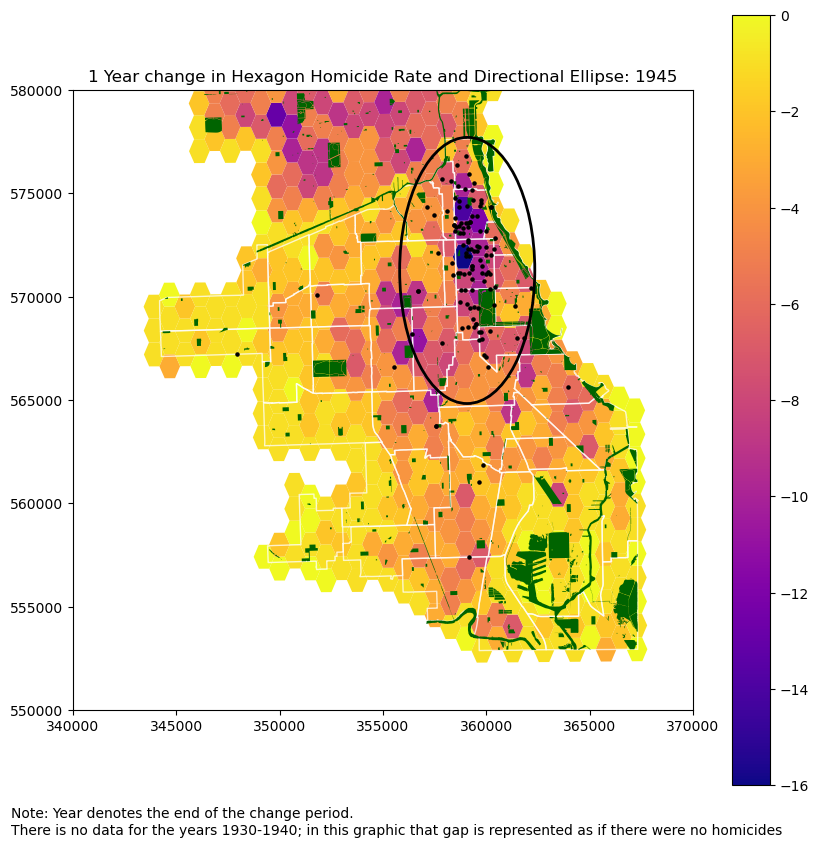

In [29]:
# adding directional ellipse and hom rate change heatmap: south side test plot

x = 1945

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(550000, 580000)
plt.xlim(340000, 370000)

map_data[map_data.year==x].plot(column='difference_1year_min', 
                            cmap='plasma', 
                            legend=True, 
                            #vmin=-18,
                            #vmax=18,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)

commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
parks_water.plot(facecolor='darkgreen', ax=ax)

if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
    print(south_hom.year.value_counts()[x] >= 5)
    plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                  facecolor='none',
                                 linewidth=2, alpha=1,
                                 )

plt.title(f'1 Year change in Hexagon Homicide Rate and Directional Ellipse: {x}')
ax.annotate('Note: Year denotes the end of the change period.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
plt.show()

In [ ]:
most_recent = 1875

for x in range(1875, 2017):
    fig, ax = plt.subplots(figsize=(10,10))

    i = x

    plt.ylim(550000, 580000)
    plt.xlim(340000, 370000)

    if x not in map_data.year.unique():
        i = most_recent
        
    map_data[map_data.year==i].plot(column='difference_1year', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=-18,
                                vmax=0,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)

    
    commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
    parks_water.plot(facecolor='darkgreen', ax=ax)
    plt.title(f'1 Year decrease in Hexagon Homicide Rate and Directional Ellipse: {x}')

    if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
        print(south_hom.year.value_counts()[x] >= 5)
        plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                    facecolor='none',
                                    linewidth=2, alpha=1,
                                    )    
    ax.annotate('Note: Year denotes the end of the change period.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
    plt.savefig(f'change_dist_south/change_dist_south_{x}.png')
    print(f'change_dist_south/change_dist_south_{x}.png')
    plt.close()
    most_recent = i

change_dist_south/change_dist_south_1875.png
change_dist_south/change_dist_south_1876.png
change_dist_south/change_dist_south_1877.png
False
change_dist_south/change_dist_south_1878.png
False
change_dist_south/change_dist_south_1879.png
False
change_dist_south/change_dist_south_1880.png
True
change_dist_south/change_dist_south_1881.png
True
change_dist_south/change_dist_south_1882.png
True
change_dist_south/change_dist_south_1883.png
True
change_dist_south/change_dist_south_1884.png
True
change_dist_south/change_dist_south_1885.png
False
change_dist_south/change_dist_south_1886.png
True
change_dist_south/change_dist_south_1887.png
False
change_dist_south/change_dist_south_1888.png
True
change_dist_south/change_dist_south_1889.png
True
change_dist_south/change_dist_south_1890.png
True
change_dist_south/change_dist_south_1891.png
True
change_dist_south/change_dist_south_1892.png
True
change_dist_south/change_dist_south_1893.png
True
change_dist_south/change_dist_south_1894.png
True
chang

In [33]:
create_gif([f'change_dist_south/change_dist_south_{x}.png' for x in range(1875,2017)], 'change_dist_south/change_dist_south_gif_1year.gif')

GIF saved as change_dist_south/change_dist_south_gif_1year.gif in change_dist_south/change_dist_south_gif_1year.gif
